In [1]:
import os, argparse, typing
os.chdir("../")

import numpy as np
import pandas as pd
import torch 

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scanpy as sc

In [3]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [5]:
n_grid = 50
nearby_cellstate = 50

train_DS = reader.MeshGrid_AnnDS(AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)

train_DS = reader.Simple_DS(n_timepoint = 3, AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)

# get msh grid cell state
s = train_DS.s
ub = train_DS.u_b
meshs = s.reshape(n_grid,n_grid,2) 

In [9]:
check_coord = []

for i in range(2500):

    ix = i//50
    iy = i%50
    
    check_coord.append(torch.all(s[i] == meshs[ix,iy]).numpy())

In [11]:
check_coord = []
for ix in range(50):
    for iy in range(50):
        i = ix*50 + iy

    check_coord.append(torch.all(s[i] == meshs[ix,iy]).numpy())

np.all(check_coord)

True

In [15]:
def indexing_mesh(i):
    ix = i//50
    iy = i%50
    return ix, iy

def indexing_flatten(ix, iy):
    return ix*50 + iy

In [16]:
def get_square(i, neighborhood):
    squares = []
    ix, iy = indexing_mesh(i)   # locate square in mesh s 
    for ixx in range(ix, ix+neighborhood):
        for iyy in range(iy, iy+neighborhood):
            squares.append(indexing_flatten(ixx, iyy))
    return squares

In [19]:
import matplotlib.pyplot as plt

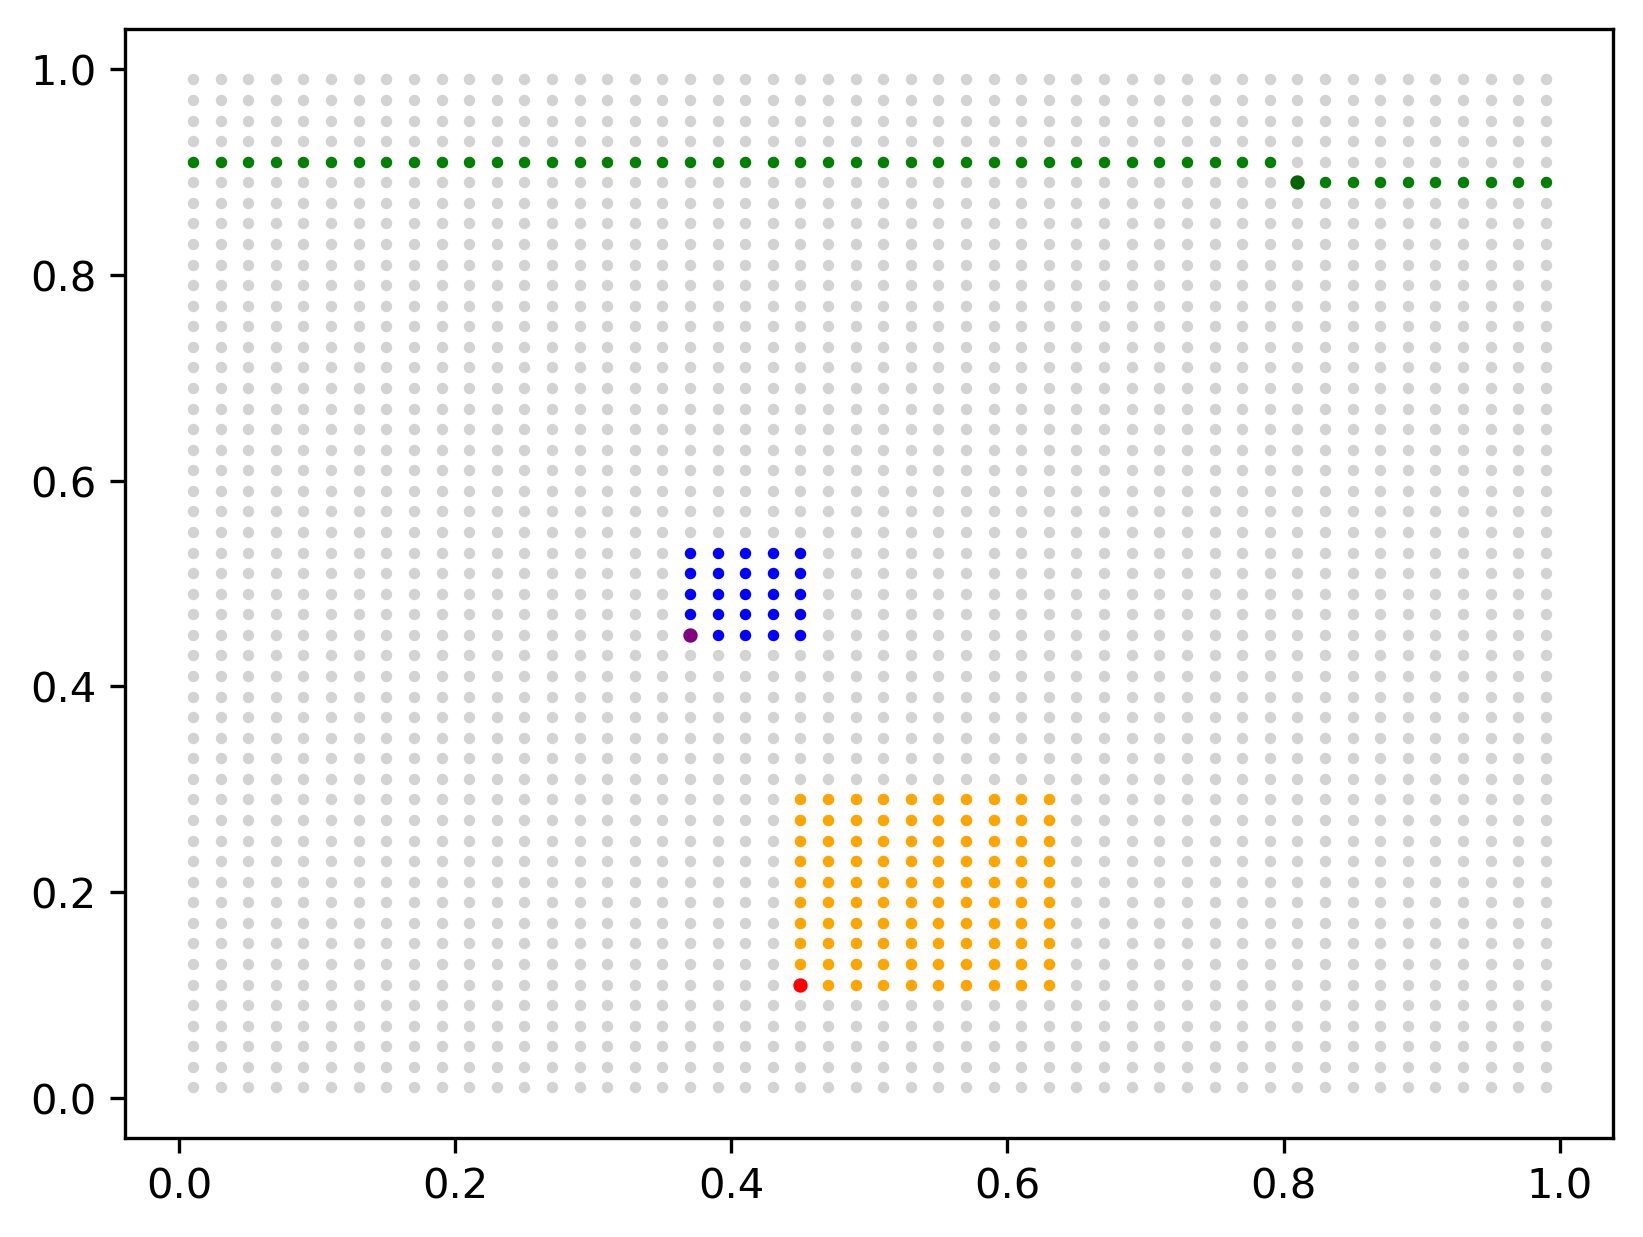

In [42]:
fig , ax = plt.subplots(1,1, dpi=300)
squares = get_square(1118, 5)
squares2 = get_square(272, 10)

i = 2240
s_range = slice(i, i+50)

plt.scatter(s[:,0], s[:,1], color='lightgray', s=3)

plt.scatter(s[s_range,0], s[s_range,1], color='green', s=3)
plt.scatter(s[i,0], s[i,1], color='darkgreen', s=6)

plt.scatter(s[squares,0], s[squares,1], color='blue', s=3)
plt.scatter(s[squares[0],0], s[squares[0],1], color='purple', s=6)

plt.scatter(s[squares2,0], s[squares2,1], color='orange', s=3)
plt.scatter(s[squares2[0],0], s[squares2[0],1], color='red', s=6)

# SimDS

In [ ]:
n_grid = 50
nearby_cellstate = 5

train_DS = reader.Simple_DS(n_timepoint = nearby_cellstate, AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid, # nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)

# get msh grid cell state
s = train_DS.s
ub = train_DS.u_b
# meshs = s.reshape(n_grid,n_grid,nearby_cellstate) 

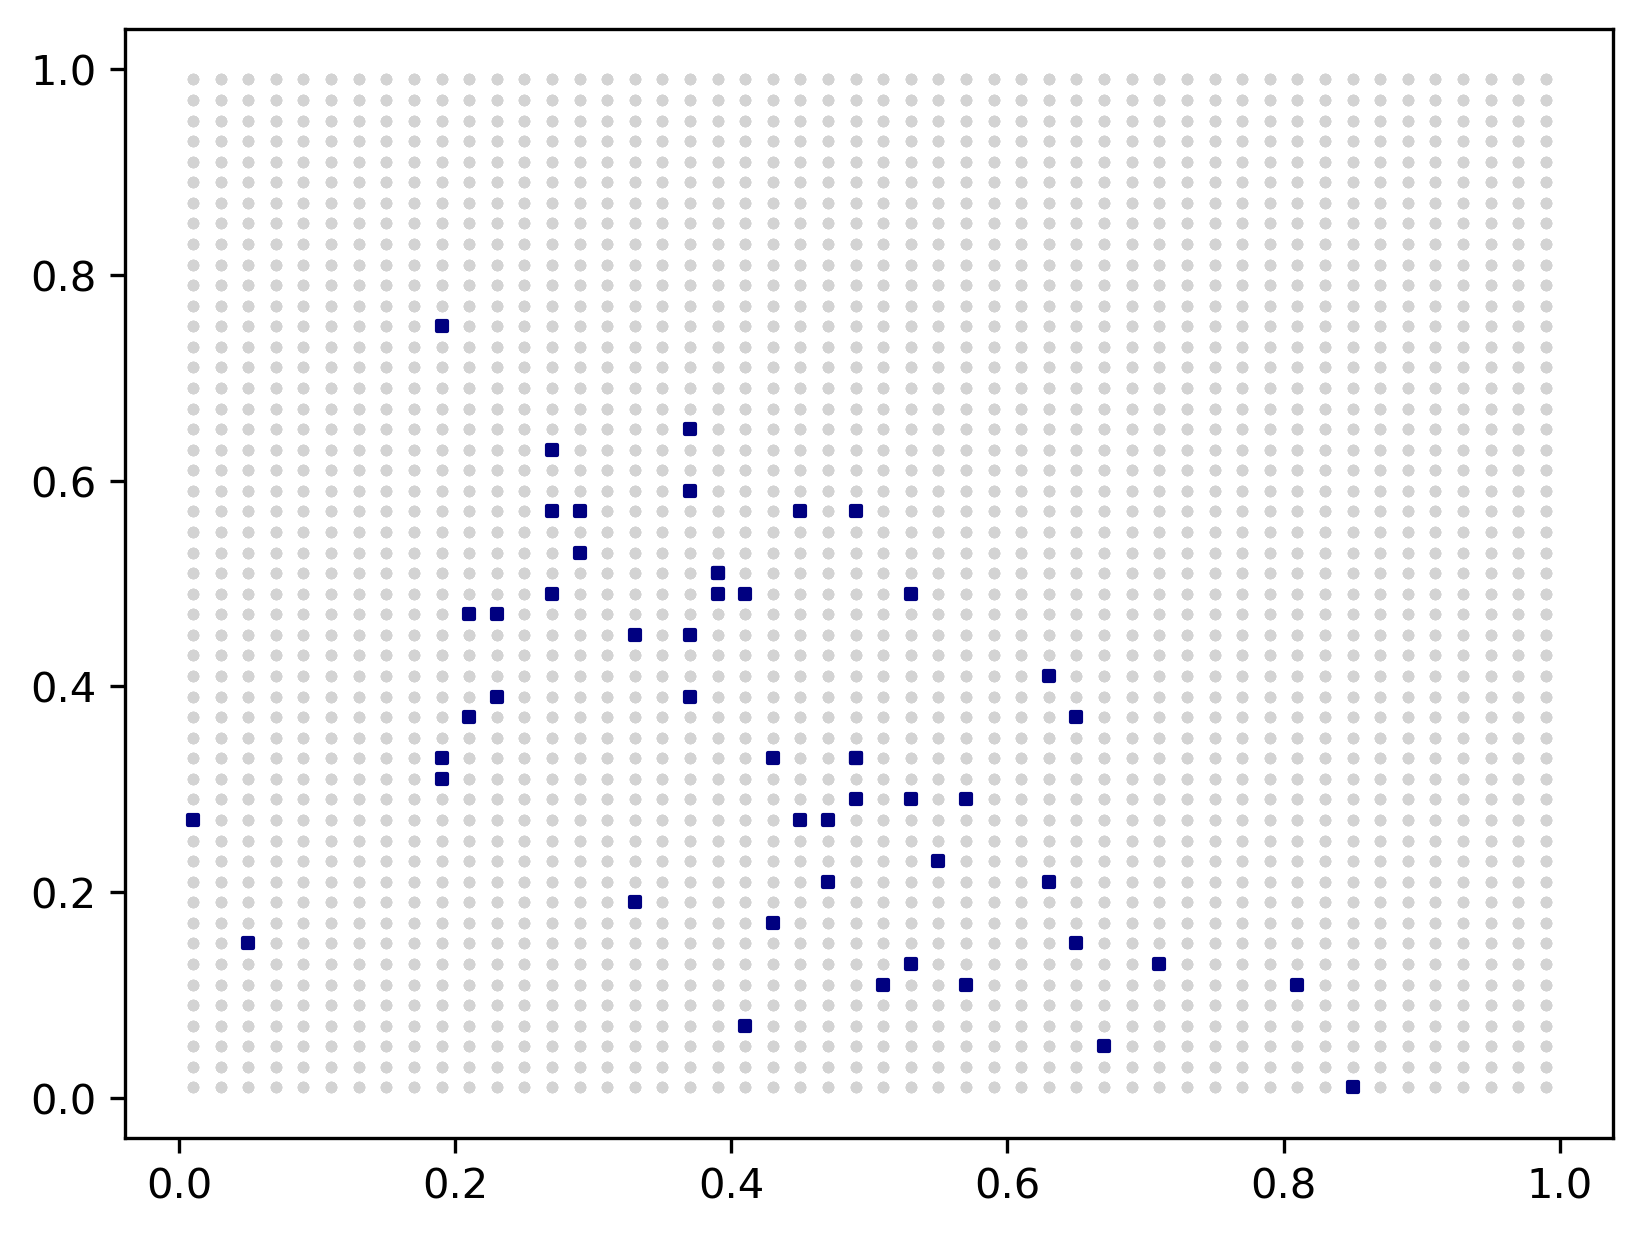

In [23]:
fig , ax = plt.subplots(1,1, dpi=300)

reindex_i = train_DS.resampling_by_density(50, p=train_DS.density_P)

plt.scatter(s[:,0], s[:,1], color='lightgray', s=3)

plt.scatter(s[reindex_i,0], s[reindex_i,1], color='navy', s=6, marker='s')
# plt.scatter(s[i,0], s[i,1], color='darkblue', s=6, marker='s')



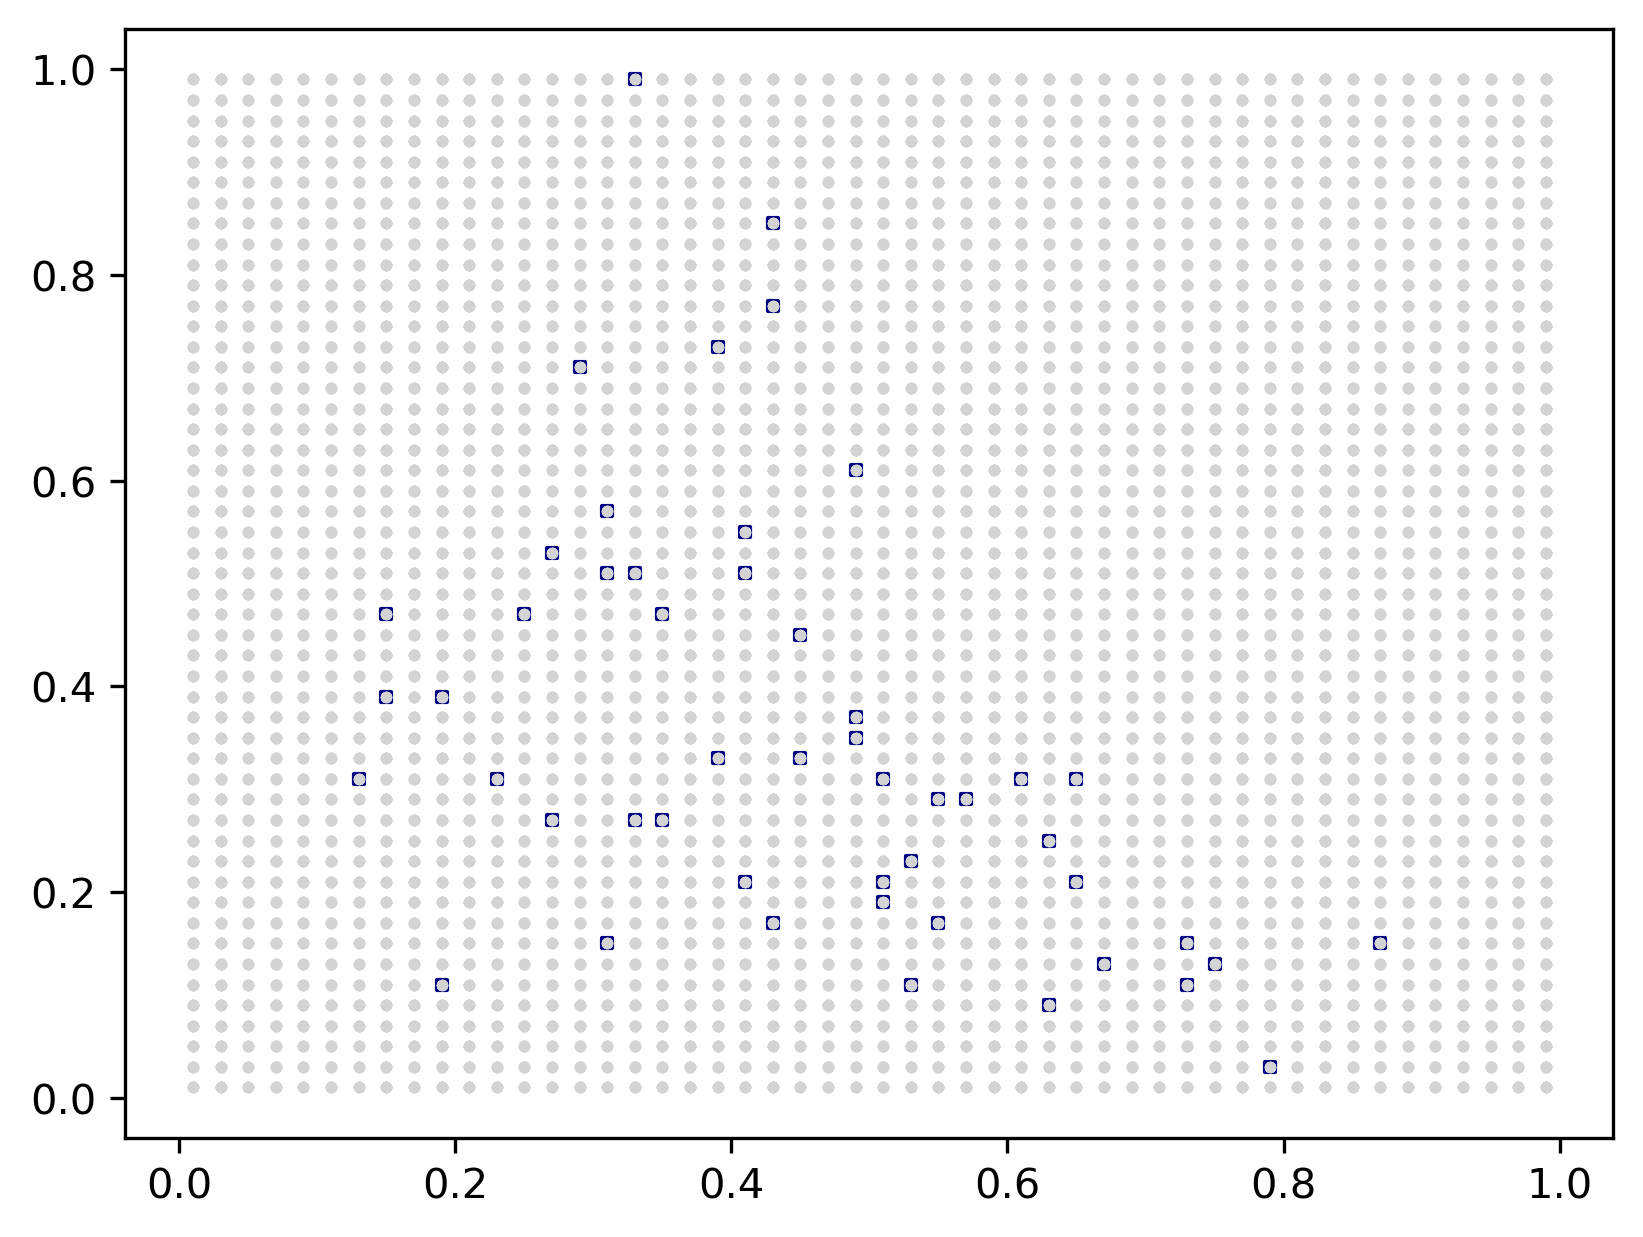

In [35]:
fig , ax = plt.subplots(1,1, dpi=300)
ax.set_xlim(0,1)         
ax.set_ylim(0,1)         

def init():
    ax.scatter(s[:,0], s[:,1], color='lightgray', s=3)

def run(data):
    if data>0:
        ax.clear()
        reindex_i = train_DS.resampling_by_density(50, p=train_DS.density_P)
        ax.scatter(s[:,0], s[:,1], color='lightgray', s=3)
        ax.scatter(s[reindex_i,0], s[reindex_i,1], color='navy', s=6, marker='s')
    else:
        pass

ani = animation.FuncAnimation(fig, run, frames=100, interval=10, init_func=init)  # make animation
ani.save('Explore_Notebook/resampling.gif', fps=5, writer='pillow') 